# Part II — How Electric Charge Reshapes a Molecule's Infrared Fingerprint
## An explanatory tour of polycyclic aromatic hydrocarbons (PAHs) · by Frederic Petrignani


## Why I'm looking at this data

I want to **predict the infrared (IR) spectra of aromatic molecules with chemical precision** — the aim of my upcoming capstone. The richest catalogue of such spectra, the **NASA Ames PAH IR Spectroscopic Database (PAHdb)**, is *computed* rather than measured: its line positions come from a quantum-chemistry (DFT) approximation, so they are realistic in shape but **not chemically exact**. Closing that gap is the long-term goal — but before trying to *improve* these spectra, I first need to **understand the molecules and what governs their infrared fingerprints**. This notebook is that exploration, and it turned up a clear, striking story.

## The molecules and the data

**Polycyclic aromatic hydrocarbons (PAHs)** are flat, fused-ring carbon molecules — among the most abundant complex molecules in interstellar space, where they radiate strongly in the infrared. I combined two sources:

- **PAHdb** — theoretical IR spectra: for each molecule, a list of emission **lines**, each with a **frequency** (cm⁻¹ — *where* it emits) and an **intensity** (km mol⁻¹ — *how strongly*).
- **PubChem** — molecular **structures** (2D depictions, molecular weight, and other descriptors).

The working set is **271 species** centred on the naphthalene family (a naphthalene-substructure sample of the much larger PAHdb library). Crucially, each molecule can exist as a **neutral** and as its **charged ions** (cation / anion) — and that turns out to matter enormously.

## The question

**What shapes a PAH's infrared fingerprint — and does its electric charge matter?**

## What I found (executive summary)

1. **Charge is the dominant factor.** Ionized PAHs (cations and anions) emit **~3–4× more** total infrared than neutral ones — *Figure 1*.
2. **Charge changes not just the loudness but the tune.** Ionization **redistributes** emission between bands: **cations almost entirely lose the 3.3 µm C–H stretch** that neutrals and anions keep — *Figure 2*.
3. **The same molecule, different light.** A per-molecule **fact sheet** shows this on a single molecule — **naphthalene** — whose anion, neutral, and cation forms share one structure but emit visibly different spectra — *Figure 3*. The fact sheet is a reusable tool: enter any molecule id to inspect its structure and charge-resolved spectra.

The through-line: **to predict a PAH's spectrum you must first know its charge** — exactly the kind of property-level understanding the capstone will need.


In [1]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.gridspec import GridSpec
from rdkit import Chem
from rdkit.Chem import Draw

# suppress warnings from final output
import warnings
warnings.simplefilter("ignore")

# consistent styling for the whole presentation
sns.set_theme(style="whitegrid", context="notebook")


In [ ]:
# load the cleaned molecule and transition tables plus the extracted molecular geometry
DATA_DIR = Path("../data")
if not (DATA_DIR / "clean").exists():
    DATA_DIR = Path("data")

molecules = pd.read_csv(DATA_DIR / "clean" / "pah_molecules_clean.csv")
transitions = pd.read_csv(DATA_DIR / "clean" / "pah_transitions_clean.csv")
geometry = pd.read_csv(DATA_DIR / "processed" / "pah_geometry.csv")

# Ordered categorical so charge always reads anion -> neutral -> cation.
charge_order = ["anion", "neutral", "cation"]
molecules["charge_state"] = pd.Categorical(
    molecules["charge_state"], categories=charge_order, ordered=True
)

print("molecules:", molecules.shape, "| transitions:", transitions.shape,
      "| geometry:", geometry.shape)


molecules: (1136, 12) | transitions: (22710, 3) | geometry: (8112, 7)


In [9]:
# --- Reusable fact-sheet helpers -------------------------------------------------
# A molecule is identified by its STRUCTURE (InChIKey), so we can gather all of its
# charge variants (anion / neutral / cation) - each a distinct PAHdb species with its
# own spectrum - and show them together. The 2D structure is the same for every charge
# state (same skeleton), so we draw it once; only the SPECTRUM changes with charge.

def get_molecule_row(uid):
    """Return one representative molecule row for a uid (the shortest-SMILES isomer)."""
    rows = molecules[molecules["uid"] == uid]
    if rows.empty:
        raise ValueError(f"uid {uid} is not in the dataset.")
    return rows.loc[rows["SMILES"].str.len().idxmin()]


def get_charge_variants(uid):
    """Return {charge_state: (uid, charge)} for charge variants sharing this structure."""
    inchikey = get_molecule_row(uid)["InChIKey"]
    variants = molecules[molecules["InChIKey"] == inchikey].drop_duplicates("uid")
    chosen = {}
    for state in charge_order:                      # anion -> neutral -> cation
        sub = variants[variants["charge_state"] == state]
        if not sub.empty:                           # prefer the smallest |charge| in a state
            best = sub.loc[sub["charge"].abs().idxmin()]
            chosen[state] = (int(best["uid"]), int(best["charge"]))
    return chosen


def draw_structure_2d(smiles, size=(460, 380)):
    """Return a 2D RDKit depiction of a SMILES string as an RGB image array."""
    return np.array(Draw.MolToImage(Chem.MolFromSmiles(smiles), size=size))


def plot_ir_spectrum(uid, ax):
    """Draw the IR stick spectrum for a molecule on `ax`, marking IR-silent lines in red."""
    tr = transitions[transitions["uid"] == uid]
    active, silent = tr[tr["intensity"] > 0], tr[tr["intensity"] == 0]
    ax.vlines(active["frequency"], 0, active["intensity"], color="steelblue", lw=1)
    ax.plot(silent["frequency"], np.full(len(silent), -0.03 * active["intensity"].max()),
            marker="|", linestyle="None", color="crimson", markersize=6, alpha=0.6)
    ax.set_ylabel("Intensity")


def make_fact_sheet(uid, fig_label=""):
    """Build an A4 fact sheet: details + 2D structure + one IR spectrum per charge state.

    `fig_label` optionally prefixes the header (e.g. "Figure 3.") for the featured render.
    """
    variants = get_charge_variants(uid)
    row = get_molecule_row(uid)
    states = [s for s in charge_order if s in variants]

    fig = plt.figure(figsize=(8.27, 11.69))
    gs = GridSpec(2 + len(states), 2, height_ratios=[0.4, 2.4] + [1.5] * len(states),
                  hspace=0.55, wspace=0.15, figure=fig)

    ax_title = fig.add_subplot(gs[0, :]); ax_title.axis("off")
    ax_title.text(0.5, 0.5, f"{row['IUPACName']}  ·  {row['formula_clean']}",
                  ha="center", va="center", fontsize=18, weight="bold")

    ax_struct = fig.add_subplot(gs[1, 0])
    ax_struct.imshow(draw_structure_2d(row["SMILES"])); ax_struct.axis("off")
    ax_struct.set_title("Structure (2D)", fontsize=11)

    ax_det = fig.add_subplot(gs[1, 1]); ax_det.axis("off")
    details = [
        ("Name", row["IUPACName"]),
        ("Formula", row["formula_clean"]),
        ("Molecular weight", f"{row['MolecularWeight']:.2f} g/mol"),
        ("Heavy atoms", int(row["HeavyAtomCount"])),
        ("Charge states shown", ", ".join(states)),
        ("Structure key", row["InChIKey"][:14] + "…"),
    ]
    ax_det.text(0.0, 0.95, "\n".join(f"{k:>19}:  {v}" for k, v in details),
                ha="left", va="top", family="monospace", fontsize=9)
    ax_det.set_title("Details", fontsize=11)

    xmax = transitions[transitions["uid"].isin(u for u, _ in variants.values())]["frequency"].max()
    first = None
    for i, state in enumerate(states):
        u, ch = variants[state]
        ax = fig.add_subplot(gs[2 + i, :], sharex=first)
        first = first or ax
        plot_ir_spectrum(u, ax)
        ax.axvspan(3000, 3150, color="orange", alpha=0.12)          # the 3.3 um C-H stretch
        total = transitions[transitions["uid"] == u]["intensity"].sum()
        ax.set_title(f"{state} (charge {ch:+d}) — total {total:.0f} km mol$^{{-1}}$",
                     fontsize=10, loc="left")
        ax.set_xlim(0, xmax * 1.02)
    ax.set_xlabel("Vibrational frequency (cm$^{-1}$)")
    first.text(3075, first.get_ylim()[1] * 0.88, "3.3 µm\nC–H stretch",
               fontsize=7, ha="center", color="darkorange")

    header = "PAH fact sheet — infrared spectrum by charge state"
    fig.suptitle(f"{fig_label} {header}".strip(), y=0.94, fontsize=10, color="0.5")
    return fig


## Visualization 1 — Ionization turns up the volume

The first question is the simplest: **does electric charge change how *much* infrared a PAH emits?** For every species we sum the intensity of all its emission lines and compare neutrals, cations, and anions on a log scale.

One thing to keep in mind while reading the axis: these intensities are an **intrinsic property of each molecule** — the strength of its vibrational bands — not a count of photons and not a brightness that depends on any particular star. So "emits more" means each molecule is a **louder infrared broadcaster per unit of excitation**, not that it happens to be lit up more. Ions sit **~3–4× higher** than neutrals. *Why* a single electron should do that comes down to the dipole moment — the intermezzo right after this figure.


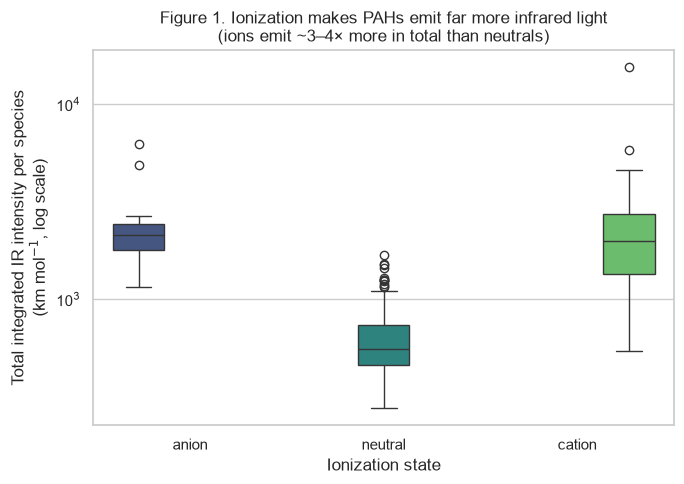

In [10]:
# Visualization 1: total integrated IR emission per species, by ionization state.
species_emission = (
    transitions.groupby("uid")["intensity"].sum().rename("total_intensity").reset_index()
    .merge(molecules.drop_duplicates("uid")[["uid", "charge_state"]], on="uid")
)

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=species_emission, x="charge_state", y="total_intensity",
            order=charge_order, hue="charge_state", palette="viridis",
            legend=False, ax=ax)
ax.set_yscale("log")
ax.set_xlabel("Ionization state")
ax.set_ylabel("Total integrated IR intensity per species\n(km mol$^{-1}$, log scale)")
ax.set_title("Figure 1. Ionization makes PAHs emit far more infrared light\n"
             "(ions emit ~3–4× more in total than neutrals)")
plt.tight_layout()
plt.show()


---

## Intermezzo — Why does ionization make a molecule emit more? It's the dipole moment

Figure 1 raises an obvious question: why should adding or removing a *single* electron make a molecule radiate several times more infrared? The answer is one of the more satisfying ideas in molecular spectroscopy, and it's worth a pause before we move on.

**A vibration only radiates if it moves charge.** Infrared light is an oscillating electric field, so a molecular vibration can absorb or emit an IR photon **only if the vibration changes the molecule's electric dipole moment** — its separation of positive and negative charge. A perfectly symmetric motion that shuffles no charge is *infrared-silent*; a motion that swings charge back and forth is a bright emitter. The strength of a band scales with the **square** of how fast the dipole changes as the atoms move:

$$I \;\propto\; \left|\frac{\partial \vec{\mu}}{\partial Q}\right|^{2}$$

where $\vec{\mu}$ is the dipole moment and $Q$ describes the atomic motion of that particular vibration.

**Ionization rearranges the electron cloud.** Stripping an electron off a PAH (a cation) or adding one (an anion) redistributes the loosely held **π electrons** that are smeared across the whole flat ring system. Because those electrons are now freer to slosh from one side of the molecule to the other as the carbon skeleton flexes, **the same vibration shifts far more charge than it did in the neutral molecule.** A larger $\partial\vec{\mu}/\partial Q$, squared, means dramatically stronger bands — which is exactly the ~3–4× jump in Figure 1.

**Nothing is created from nothing.** This is intrinsic radiative *efficiency*, not free energy. In space a PAH is heated by absorbing a single stellar UV photon and then cools by fluorescing that energy back out in the infrared. Ionization doesn't hand the molecule extra energy — it changes **how efficiently, and in which bands,** it re-radiates what it absorbed. And that "which bands" is precisely the next question: charge doesn't only change the *volume*, it changes the *tune*.


## Visualization 2 — …and changes the tune

Charge doesn't only change *loudness* — it changes **which bands light up**. Weighting every emission line by its intensity and faceting by charge state shows the spectral *shape* for each: the striking result is that **cations almost entirely lose the 3.3 µm C–H stretch (~3050 cm⁻¹)** that neutrals and anions keep.


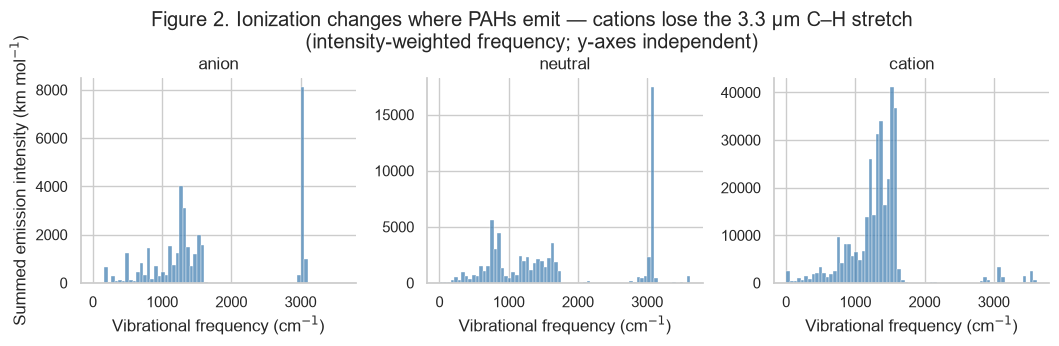

In [13]:
# Visualization 2: emission profile (intensity-weighted frequency) faceted by charge state.
tr_charge = transitions.merge(
    molecules.drop_duplicates("uid")[["uid", "charge_state"]], on="uid"
)

g = sns.displot(
    data=tr_charge, x="frequency", weights="intensity",
    col="charge_state", col_order=charge_order,
    bins=70, height=3.4, aspect=1.05, color="steelblue",
    facet_kws={"sharey": False},   # compare shape; absolute totals differ (see Visualization 1)
)
g.set_axis_labels("Vibrational frequency (cm$^{-1}$)", "Summed emission intensity (km mol$^{-1}$)")
g.set_titles("{col_name}")
# Reserve headroom so the two-line title clears the panel titles (anion / neutral / cation).
g.figure.subplots_adjust(top=0.80)
g.figure.suptitle("Figure 2. Ionization changes where PAHs emit — cations lose the 3.3 µm C–H stretch\n"
                  "(intensity-weighted frequency; y-axes independent)", y=1.0)
plt.show()


## Visualization 3 — The molecule fact sheet (the story on one molecule)

Now we zoom from the whole population down to a single molecule. Enter a PAHdb `uid` and the **fact sheet** gathers that molecule's **structure** (drawn once — the skeleton is the same for every charge state) and an **infrared spectrum for each charge state it exists in** (anion / neutral / cation), stacked for comparison.

This is the population story made personal: below is **naphthalene**, and the highlighted **3.3 µm C–H stretch** band shows the exact same effect as Visualization 2 — a strong peak for the **anion** and **neutral**, but **essentially gone for the cation**.

*Reading the spectra:* blue sticks are emission lines (height = intensity); the small **red ticks** along the baseline mark **IR-silent** (symmetry-forbidden) modes; the **orange band** highlights the 3.3 µm C–H stretch region.


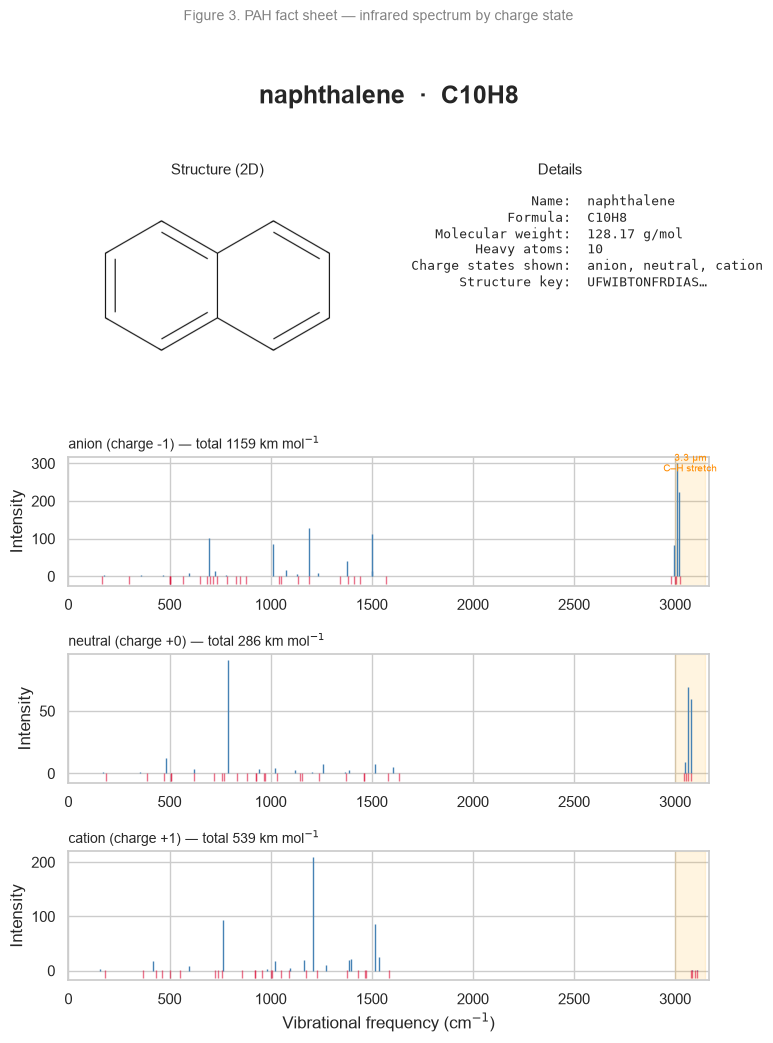

In [12]:
# Fact sheet for a chosen molecule - change the uid to render any species in the dataset.
make_fact_sheet(330, fig_label="Figure 3.")   # naphthalene (anion / neutral / cation)
plt.show()


### Submission
If you are using classroom workspace, you can choose from the following two ways of submission:

1. **Submit from the workspace**. Make sure you have removed the example project from the /home/workspace directory. You must submit the following files:
   - Part_I_notebook.ipynb
   - Part_I_notebook.html or pdf
   - Part_II_notebook.ipynb
   - Part_II_notebook.html or pdf


2. **Submit a zip file on the last page of this project lesson**. In this case, open the Jupyter terminal and run the command below to generate a ZIP file. 
```bash
zip -r my_project.zip .
```
The command abobve will ZIP every file present in your /home/workspace directory. Next, you can download the zip to your local, and follow the instructions on the last page of this project lesson.
